# Conformer CTC for Mozilla Commonvoice English ASR

This notebook trains a Conformer-CTC model from scratch for automatic speech recognition, 
targeting English using the Mozilla Common Voice v24 dataset.

## Dataset
- **Common Voice v24 EN-AU** — 44,500 crowd-sourced Australian English recordings used for training, 
with 2,000 samples each held out for validation and test.

## Model
A Conformer encoder (12 layers, 256 dim, 4 heads) with a linear CTC head trained over a 
31-character vocabulary. The Conformer combines convolutional and self-attention layers, 
making it well suited to capturing both local acoustic features and long-range dependencies in speech.

## Training
- CTC loss with greedy decoding
- SpecAugment (frequency and time masking) for regularisation
- Additive noise augmentation on raw waveforms
- OneCycleLR scheduler with 10% warmup
- Early stopping with patience of 5 epochs based on validation WER

## Evaluation
The final model is evaluated on a held-out test set using:
- Word Error Rate (WER)
- Character Error Rate (CER)

Sample predictions are displayed alongside ground truth transcripts.

In [19]:
# 0) Install deps (Kaggle) — pinned to avoid dependency conflicts
!pip -q install \
  jiwer==3.0.4 \
  soundfile==0.12.1 \


import os
import re
import glob
import random
from functools import partial
from collections import Counter


import numpy as np
import pandas as pd

import torch
import torchaudio
import torch.nn as nn
import torchaudio.models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from jiwer import wer as jiwer_wer, cer as jiwer_cer

print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("gpu memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

torch: 2.9.0+cu126
torchaudio: 2.9.0+cu126
cuda available: True
gpu: Tesla P100-PCIE-16GB
gpu memory (GB): 17.06


In [20]:
# Reproducibility + output
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

OUTPUT_DIR = "/kaggle/working/conformer_en_commonvoice_local"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## 1) Load dataset

In [21]:
def find_first(patterns, roots=("/kaggle/input", "/kaggle/working", "/kaggle")):
    for root in roots:
        for pat in patterns:
            hits = glob.glob(os.path.join(root, "**", pat), recursive=True)
            if hits:
                return hits[0]
    return None

split_csv = find_first(["commonvoice-v24_en-AU-split.csv", "*split*.csv"])
main_csv  = find_first(["commonvoice-v24_en-AU.csv", "*en-AU*.csv"])

print("Found split CSV:", split_csv)
print("Found main  CSV:", main_csv)

if main_csv is None and split_csv is None:
    raise FileNotFoundError("Could not find your Common Voice CSVs under /kaggle/input or /kaggle/working.")

base_dir = os.path.dirname(split_csv if split_csv else main_csv)
print("Base dir:", base_dir)

audio_dir_candidates = [
    os.path.join(base_dir, "audio_files"),
    os.path.join(base_dir, "clips"),
    os.path.join(base_dir, "audio"),
]
audio_dir = next((d for d in audio_dir_candidates if os.path.isdir(d)), None)
print("Audio dir:", audio_dir)
if audio_dir is None:
    raise FileNotFoundError("Could not find audio directory (audio_files/clips/audio).")

Found split CSV: /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/commonvoice-v24_en-AU-split.csv
Found main  CSV: /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/commonvoice-v24_en-AU.csv
Base dir: /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU
Audio dir: /kaggle/input/datasets/eddiehoogewerf/mozilla-commonvoice/commonvoice-v24_en-AU/audio_files


## 2) Load CSVs and Train/Test/Split

In [5]:
df = pd.read_csv(main_csv)

df["audio_path"] = df["path"].apply(lambda x: os.path.join(audio_dir, os.path.basename(str(x))))
df["transcript"] = df["sentence"].astype(str)

df = df[df["audio_path"].apply(os.path.exists)].reset_index(drop=True)

print("Rows with existing audio:", len(df))
df.head()

Rows with existing audio: 55673


,Unnamed: 0,client_id,path,sentence_id,sentence,sentence_domain,up_votes,down_votes,age,gender,accents,variant,locale,segment,duration_ms,audio_path,transcript
0,182,0621ad6390e651ff1e39b23f74e8d624bd8ba0957d6a19...,common_voice_en_30513358.mp3,1f08423cd2153df43fb7c18ddd24edfea7be733046c26d...,Princess Vilas herself also contributed person...,NaN,4,0,teens,male_masculine,Australian English,NaN,en,NaN,7.387500,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Princess Vilas herself also contributed person...
1,725,18bea6bb076cd9638518d93b4af353c3c329d059789e11...,common_voice_en_43618790.mp3,fe3f016c86bea44ab149bc2537de58f16051d8274099a7...,He has also served in the Chamber of Deputies.,NaN,2,0,NaN,NaN,Australian English,NaN,en,NaN,6.307500,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,He has also served in the Chamber of Deputies.
2,885,1db7f61c407a3cdce51e21ae1871ef9ae3ed74d79415ba...,common_voice_en_21099981.mp3,48e620d96dda152eeec48e28f7b0dde29625591bdc44cd...,Most of his subjects were found in Devon and C...,NaN,2,0,thirties,male_masculine,Australian English,NaN,en,NaN,7.949625,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Most of his subjects were found in Devon and C...
3,984,2144a6feb6a906b220cbba00f37b56084bd2d60cce773e...,common_voice_en_39588772.mp3,e3d037f2c263d604b0bb1ef837b1fc7ee7f80d5336031c...,Shots rang out as they fled towards the Austri...,NaN,2,0,NaN,NaN,Australian English,NaN,en,NaN,5.515500,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Shots rang out as they fled towards the Austri...
4,1021,22b4048e01f359c779cf9a692f5da7512bfd7ef8c9fff2...,common_voice_en_37211578.mp3,cdfb0356e09201212c123e83ab27e43c48a62b6ce8520d...,The system is based on electromagnetic induction.,NaN,2,0,NaN,NaN,Australian English,NaN,en,NaN,4.055656,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,The system is based on electromagnetic induction.


In [7]:
# Filters, sampling, and split creation
MIN_AUDIO_SEC = 0.2
MAX_AUDIO_SEC = 15.0

def get_duration_sec(path):
    try:
        info = torchaudio.info(path)
        return info.num_frames / info.sample_rate
    except Exception:
        try:
            wav, sr = torchaudio.load(path)
            return wav.shape[-1] / sr
        except Exception:
            return None

def normalize_for_metrics(s):
    s = s.lower()
    s = re.sub(r"\[[^\]]*\]", " ", s)
    s = re.sub(r"[^a-z' ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# compute durations
df["duration"] = df["audio_path"].apply(get_duration_sec)
df = df.dropna(subset=["duration"]).reset_index(drop=True)
df = df[(df["duration"] >= MIN_AUDIO_SEC) & (df["duration"] <= MAX_AUDIO_SEC)].reset_index(drop=True)

# remove empty transcripts
df["transcript"] = df["transcript"].astype(str).str.strip()
df = df[df["transcript"].str.len() >= 2].reset_index(drop=True)

df["text_norm"] = df["transcript"].apply(normalize_for_metrics)

print("After filtering:", len(df), "rows")
df[["audio_path","transcript","duration"]].head()

After filtering: 55668 rows


,audio_path,transcript,duration
0,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Princess Vilas herself also contributed person...,7.380
1,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,He has also served in the Chamber of Deputies.,6.300
2,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Most of his subjects were found in Devon and C...,7.944
3,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,Shots rang out as they fled towards the Austri...,5.508
4,/kaggle/input/datasets/eddiehoogewerf/mozilla-...,The system is based on electromagnetic induction.,4.032


In [8]:
# train test split
df_shuf = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n = len(df_shuf)
n_train = int(0.8*n)
n_val = int(0.1*n)

train_df = df_shuf.iloc[:n_train].copy()
val_df = df_shuf.iloc[n_train:n_train+n_val].copy()
test_df = df_shuf.iloc[n_train+n_val:].copy()

print("Split sizes:", len(train_df), len(val_df), len(test_df))

Split sizes: 44534 5566 5568


## 3) EDA


--- TRAIN ---
N: 44534
Duration mean: 5.031 p95: 7.944
Text len mean: 55.22 p95: 89.0
Top 10 words: [('the', 29693), ('of', 11006), ('a', 10546), ('and', 9554), ('to', 8925), ('in', 8805), ('is', 7903), ('was', 6427), ('it', 4491), ('he', 4403)]

--- VAL ---
N: 5566
Duration mean: 5.027 p95: 7.956
Text len mean: 55.39 p95: 89.0
Top 10 words: [('the', 3699), ('of', 1376), ('a', 1354), ('and', 1224), ('in', 1101), ('to', 1045), ('is', 989), ('was', 833), ('it', 615), ('he', 547)]

--- TEST ---
N: 5568
Duration mean: 5.031 p95: 8.016
Text len mean: 54.99 p95: 89.0
Top 10 words: [('the', 3803), ('a', 1322), ('of', 1316), ('to', 1146), ('and', 1143), ('in', 1096), ('is', 1030), ('was', 779), ('it', 579), ('he', 560)]


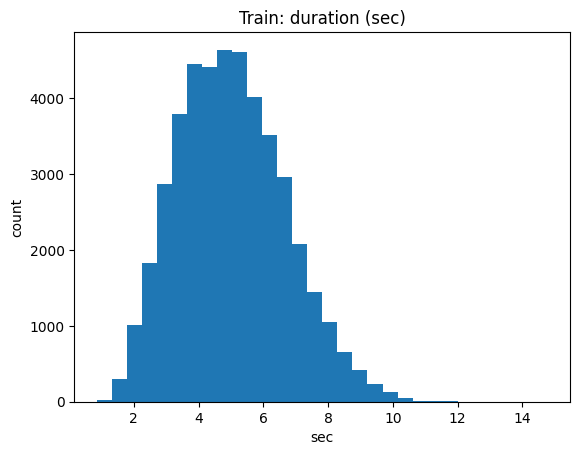

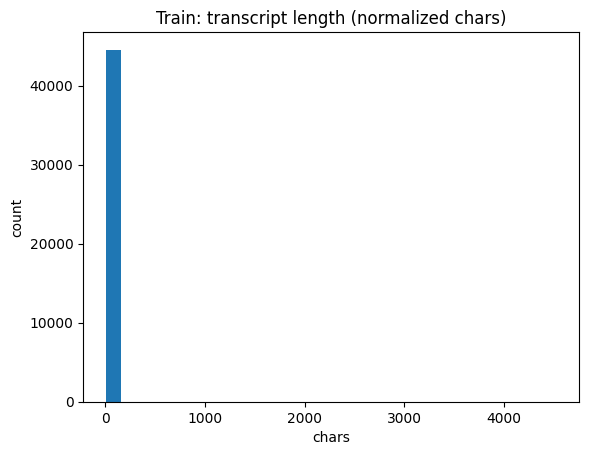

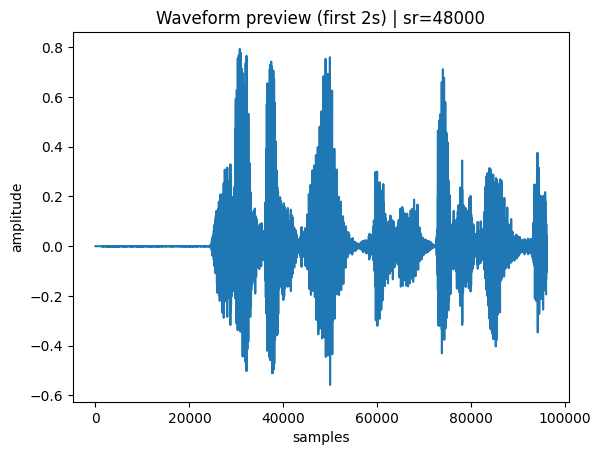

Example transcript: Trappers Lake is an excellent fishing lake for cutthroat trout.


In [9]:
def eda_basic(df_, name):
    print(f"\n--- {name} ---")
    print("N:", len(df_))
    print("Duration mean:", round(df_['duration'].mean(), 3), "p95:", round(df_['duration'].quantile(0.95), 3))
    tl = df_["text_norm"].str.len()
    print("Text len mean:", round(tl.mean(), 2), "p95:", round(tl.quantile(0.95), 2))
    words = Counter(" ".join(df_["text_norm"].tolist()).split())
    print("Top 10 words:", words.most_common(10))

eda_basic(train_df, "TRAIN")
eda_basic(val_df, "VAL")
eda_basic(test_df, "TEST")

plt.figure()
plt.hist(train_df["duration"], bins=30)
plt.title("Train: duration (sec)")
plt.xlabel("sec"); plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(train_df["text_norm"].str.len(), bins=30)
plt.title("Train: transcript length (normalized chars)")
plt.xlabel("chars"); plt.ylabel("count")
plt.show()

# waveform preview
ex_path = train_df.iloc[0]["audio_path"]
wav, sr = torchaudio.load(ex_path)
wav = wav.mean(dim=0) if wav.shape[0] > 1 else wav.squeeze(0)
plt.figure()
plt.plot(wav[: min(len(wav), sr*2)].numpy())
plt.title(f"Waveform preview (first 2s) | sr={sr}")
plt.xlabel("samples"); plt.ylabel("amplitude")
plt.show()

print("Example transcript:", train_df.iloc[0]["transcript"])

## 4) Preprocessing

In [11]:
_resamplers = {}

def trim_silence(wave: torch.Tensor, thr: float = 0.01):
    if wave.numel() < 10:
        return wave
    mask = wave.abs() > thr
    if mask.any():
        i0 = int(mask.int().argmax())
        i1 = int(len(mask) - mask.int().flip(0).argmax())
        trimmed = wave[i0:i1]
        if trimmed.numel() < 400:
            return wave
        return trimmed
    return wave

def load_audio_16k_mono(path: str, augment: bool = False, do_trim: bool = False):
    wav, sr = torchaudio.load(path)  # [C, T]
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    wav = wav.squeeze(0)
    if sr != 16000:
        key = (sr, 16000)
        if key not in _resamplers:
            _resamplers[key] = torchaudio.transforms.Resample(sr, 16000)
        wav = _resamplers[key](wav)
    if do_trim:
        wav = trim_silence(wav)
    if augment:
        noise = torch.randn_like(wav) * 0.005
        wav = wav + noise
    return wav

class ASRDataset(torch.utils.data.Dataset):
    def __init__(self, df_: pd.DataFrame):
        self.df = df_.reset_index(drop=True)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        return {"audio_path": r.audio_path, "text": r.transcript, "text_norm": r.text_norm}

train_ds = ASRDataset(train_df)
val_ds   = ASRDataset(val_df)
test_ds  = ASRDataset(test_df)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))

Dataset sizes: 44534 5566 5568


In [12]:
VOCAB = [
    "<blank>",
    " ",
    "a","b","c","d","e","f","g","h","i","j",
    "k","l","m","n","o","p","q","r","s","t",
    "u","v","w","x","y","z","'", "-", "|"
]

char2id = {c: i for i, c in enumerate(VOCAB)}
id2char = {i: c for c, i in char2id.items()}
BLANK_ID = 0

def text_to_ids(text: str):
    return [char2id[c] for c in text if c in char2id]

## 5) Feature extraction

In [14]:
mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    hop_length=160,
    n_mels=80
)
to_db = torchaudio.transforms.AmplitudeToDB()
norm_layer = nn.InstanceNorm1d(80, affine=False)

def apply_spec_augment(feat):
    # feat: [Mel, Time] — functional API, stateless, safe across DataLoader workers
    feat = torchaudio.functional.mask_along_axis(feat, mask_param=15, mask_value=0.0, axis=0)  # freq
    feat = torchaudio.functional.mask_along_axis(feat, mask_param=35, mask_value=0.0, axis=1)  # time
    feat = torchaudio.functional.mask_along_axis(feat, mask_param=35, mask_value=0.0, axis=1)  # time x2
    return feat

def collate_fn(batch, augment=False):
    waves, labels = [], []
    for b in batch:
        wav = load_audio_16k_mono(b["audio_path"], augment=augment, do_trim=True)
        waves.append(wav)
        labels.append(torch.tensor(text_to_ids(b["text_norm"]), dtype=torch.long))

    feats = [to_db(mel(w)) for w in waves]

    if augment:
        feats = [apply_spec_augment(f) for f in feats]

    # pad_sequence expects [Time, Mel] → result: [Batch, Time, Mel]
    feats_padded = torch.nn.utils.rnn.pad_sequence(
        [f.transpose(0, 1) for f in feats], batch_first=True
    )

    # InstanceNorm1d expects [Batch, Channels, Time]
    feats_padded = norm_layer(feats_padded.transpose(1, 2)).transpose(1, 2)

    feat_lens = torch.tensor([f.shape[-1] for f in feats], dtype=torch.long)
    label_lens = torch.tensor([len(l) for l in labels], dtype=torch.long)
    labels_padded = torch.nn.utils.rnn.pad_sequence(
        labels, batch_first=True, padding_value=BLANK_ID
    )

    return feats_padded, feat_lens, labels_padded, label_lens

## 6) Torchaudio CTC Conformer model + greedy decoder

In [15]:
class ConformerForCTC(nn.Module):
    def __init__(self, input_dim, num_classes, 
                 encoder_dim=256, num_layers=12, num_heads=4):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, encoder_dim)
        self.encoder = torchaudio.models.Conformer(
            input_dim=encoder_dim,
            num_heads=num_heads,
            ffn_dim=encoder_dim * 4,
            num_layers=num_layers,
            depthwise_conv_kernel_size=31,
            dropout=0.1
        )
        self.classifier = nn.Linear(encoder_dim, num_classes)

    def forward(self, x, lengths):
        x = self.input_projection(x)
        x, out_lens = self.encoder(x, lengths) 
        logits = self.classifier(x)
        return logits, out_lens



In [26]:
def ctc_greedy_decode(logits):
    ids = logits.argmax(dim=-1)
    results = []
    for seq in ids:
        prev = BLANK_ID
        out = []
        for i in seq.tolist():
            if i != prev and i != BLANK_ID:
                out.append(id2char[i])
            prev = i
        results.append("".join(out))
    return results

## 7) Training

In [ ]:
EPOCHS = 25
BATCH_SIZE = 16
GRAD_ACCUM = 2
LR = 3e-4
WD = 1e-6

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=partial(collate_fn, augment=True),  
    num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=partial(collate_fn, augment=False),
    num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=partial(collate_fn, augment=False),
    num_workers=4, pin_memory=True
)

model = ConformerForCTC(input_dim=80, num_classes=len(id2char)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scaler = torch.amp.GradScaler("cuda")

effective_steps_per_epoch = len(train_loader) // GRAD_ACCUM
total_steps = effective_steps_per_epoch * EPOCHS

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=LR, 
    total_steps=total_steps,
    pct_start=0.1
)

criterion = torch.nn.CTCLoss(blank=BLANK_ID, zero_infinity=True)

best_wer = float("inf")
patience, patience_counter = 5, 0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for step, (x, x_lens, y, y_lens) in enumerate(train_loader):
        x, x_lens = x.to(DEVICE), x_lens.to(DEVICE)
        y, y_lens = y.to(DEVICE), y_lens.to(DEVICE)

        with torch.amp.autocast(device_type=DEVICE.type):
            logits, out_lens = model(x, x_lens)
            log_probs = logits.log_softmax(dim=-1).transpose(0, 1) 
            loss = criterion(log_probs, y, out_lens, y_lens) / GRAD_ACCUM

        scaler.scale(loss).backward()

        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step() 
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * GRAD_ACCUM 

    model.eval()
    val_preds, val_refs = [], []
    with torch.no_grad():
        for val_x, val_x_lens, val_y, val_y_lens in val_loader:
            val_x, val_x_lens = val_x.to(DEVICE), val_x_lens.to(DEVICE)
            with torch.amp.autocast(device_type=DEVICE.type):
                v_logits, v_out_lens = model(val_x, val_x_lens)
            val_preds.extend(ctc_greedy_decode(v_logits.cpu()))
            val_refs.extend([
                "".join(id2char[int(i)] for i in row[:l])
                for row, l in zip(val_y, val_y_lens)
            ])

    val_wer = jiwer_wer(val_refs, val_preds)
    val_cer = jiwer_cer(val_refs, val_preds)
    print(f"Epoch {epoch+1} | loss={total_loss/len(train_loader):.4f} | val WER={val_wer:.3f} | val CER={val_cer:.3f}")
    
    if val_wer < best_wer:
        best_wer = val_wer
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_model.pt"))
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    model.train()

Epoch 1 | loss=2.8668 | val WER=0.999 | val CER=0.649
Epoch 2 | loss=1.9269 | val WER=0.923 | val CER=0.497
Epoch 3 | loss=1.6434 | val WER=0.896 | val CER=0.448
Epoch 4 | loss=1.4682 | val WER=0.855 | val CER=0.400
Epoch 5 | loss=1.3680 | val WER=0.831 | val CER=0.385
Epoch 6 | loss=1.2993 | val WER=0.812 | val CER=0.363
Epoch 7 | loss=1.2379 | val WER=0.777 | val CER=0.346
Epoch 8 | loss=1.1746 | val WER=0.752 | val CER=0.322
Epoch 9 | loss=1.1133 | val WER=0.731 | val CER=0.309
Epoch 10 | loss=1.0923 | val WER=0.721 | val CER=0.304
Epoch 11 | loss=1.0363 | val WER=0.698 | val CER=0.287
Epoch 12 | loss=0.9854 | val WER=0.670 | val CER=0.273
Epoch 13 | loss=0.9503 | val WER=0.665 | val CER=0.266
Epoch 14 | loss=0.8987 | val WER=0.632 | val CER=0.250
Epoch 15 | loss=0.8447 | val WER=0.619 | val CER=0.242
Epoch 16 | loss=0.8045 | val WER=0.599 | val CER=0.234
Epoch 17 | loss=0.7686 | val WER=0.584 | val CER=0.225
Epoch 18 | loss=0.7281 | val WER=0.571 | val CER=0.219
Epoch 19 | loss=0.6

## 8) Evaluation

In [ ]:
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "best_model.pt"), map_location=DEVICE))
model.eval()

preds, refs = [], []
with torch.no_grad():
    for x, x_lens, y, y_lens in test_loader:
        x, x_lens = x.to(DEVICE), x_lens.to(DEVICE)
        logits, _ = model(x, x_lens)
        texts = ctc_greedy_decode(logits.cpu())
        preds.extend(texts)
        refs.extend(
            ["".join(id2char[int(i)] for i in row[:l]) for row, l in zip(y, y_lens)]
        )

print("WER:", jiwer_wer(refs, preds))
print("CER:", jiwer_cer(refs, preds))

WER: 0.5390787518573551
CER: 0.19874392948238528


In [29]:
model.eval()
NUM_SAMPLES = 10

with torch.no_grad():
    sample_x, sample_x_lens, sample_y, sample_y_lens = next(iter(test_loader))
    sample_x = sample_x[:NUM_SAMPLES].to(DEVICE)
    sample_x_lens = sample_x_lens[:NUM_SAMPLES].to(DEVICE)

    logits, _ = model(sample_x, sample_x_lens)
    predictions = ctc_greedy_decode(logits.cpu())

targets = [
    "".join([id2char[j.item()] for j in sample_y[i] if j.item() != BLANK_ID])
    for i in range(NUM_SAMPLES)
]

results_df = pd.DataFrame({"True": targets, "Predicted": predictions})
results_df.index += 1
results_df.style.set_properties(**{
    "text-align": "left",
    "white-space": "normal",
    "max-width": "600px"
}).set_table_styles([
    {"selector": "th", "props": [("text-align", "left"), ("font-weight", "bold")]},
    {"selector": "tr:nth-child(even)", "props": [("background-color", "#f2f2f2")]}
])

,True,Predicted
1,the woman sat down and told him to be seated as well,womans at bown and toldim to be sek idil
2,and back to kansas she asked eagerly,enbactor cansis she asked to eagerly o
3,the wind vanishes the words,the win vanishes the words
4,during this time he studied composition privately with jeremy dale roberts,during this time he studied composition privately with germany dell roberts
5,other events and ranger programs are available throughout the rest of the year,other reventse and ranger programs are available throughout the rest of the year
6,an autopsy was done and adult trematodes were found in the lungs,an autopty was don and adult tramatods were found in the longs
7,did she ever marry the girl,this se ever marrie the gol
8,the dinkas' pastoral lifestyle is also reflected in their religious beliefs and practices,the dincos pas tornal life stale is also reflected in their relicious relise and practices
9,he was beyond my skill to quiet or console,be was beond misco t quime fol comsul
10,absolutely despicable that gingerbread men are forced to live in houses made of their own flesh,psololy dispicable the tingerpreat man ae four te lev an houses made a the own flesh
